In [1]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation

In [2]:
import pandas as pd
df = pd.read_excel('lophoc.xlsx', sheet_name= 'data')
df

,Sức khỏe,Thời tiết,Kết quả
0,ốm,u ám,nghỉ
1,ốm,mưa,nghỉ
2,ốm,nắng,nghỉ
3,ốm,u ám,học
4,tốt,u ám,học
5,tốt,mưa,học
6,tốt,nắng,nghỉ


In [3]:
df.head()

,Sức khỏe,Thời tiết,Kết quả
0,ốm,u ám,nghỉ
1,ốm,mưa,nghỉ
2,ốm,nắng,nghỉ
3,ốm,u ám,học
4,tốt,u ám,học


In [4]:
#Tập dữ liệu input (đặc trưng) và output (mục tiêu)
x = df.iloc[:,:-1]#feature
y = df.iloc[:,-1] #

In [5]:
from sklearn.preprocessing import LabelEncoder
encHealth = LabelEncoder()
x['Sức khỏe'] = encHealth.fit_transform(x['Sức khỏe'])
encWeather = LabelEncoder()
x['Thời tiết'] = encHealth.fit_transform(x['Thời tiết'])

/var/folders/n5/1571yh0x7_g0dbltk948d2tm0000gn/T/ipykernel_11061/1740432085.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Sức khỏe'] = encHealth.fit_transform(x['Sức khỏe'])
/var/folders/n5/1571yh0x7_g0dbltk948d2tm0000gn/T/ipykernel_11061/1740432085.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Thời tiết'] = encHealth.fit_transform(x['Thời tiết'])


In [6]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=34) # 80% training and 30% test

In [7]:
X_train

,Sức khỏe,Thời tiết
4,0,2
6,0,1
5,0,0
2,1,1
1,1,0


In [8]:
y_train

4     học
6    nghỉ
5     học
2    nghỉ
1    nghỉ
Name: Kết quả, dtype: object

In [9]:
modeIDT = DecisionTreeClassifier (criterion='entropy',max_depth=3)
#train
modeIDT = modeIDT.fit(X_train,y_train)

[Text(0.6, 0.875, 'Sức khỏe <= 0.5\nentropy = 0.971\nsamples = 5\nvalue = [2, 3]\nclass = nghỉ'),
 Text(0.4, 0.625, 'Thời tiết <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [2, 1]\nclass = học'),
 Text(0.2, 0.375, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = học'),
 Text(0.6, 0.375, 'Thời tiết <= 1.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]\nclass = học'),
 Text(0.4, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = nghỉ'),
 Text(0.8, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = học'),
 Text(0.8, 0.625, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = nghỉ')]

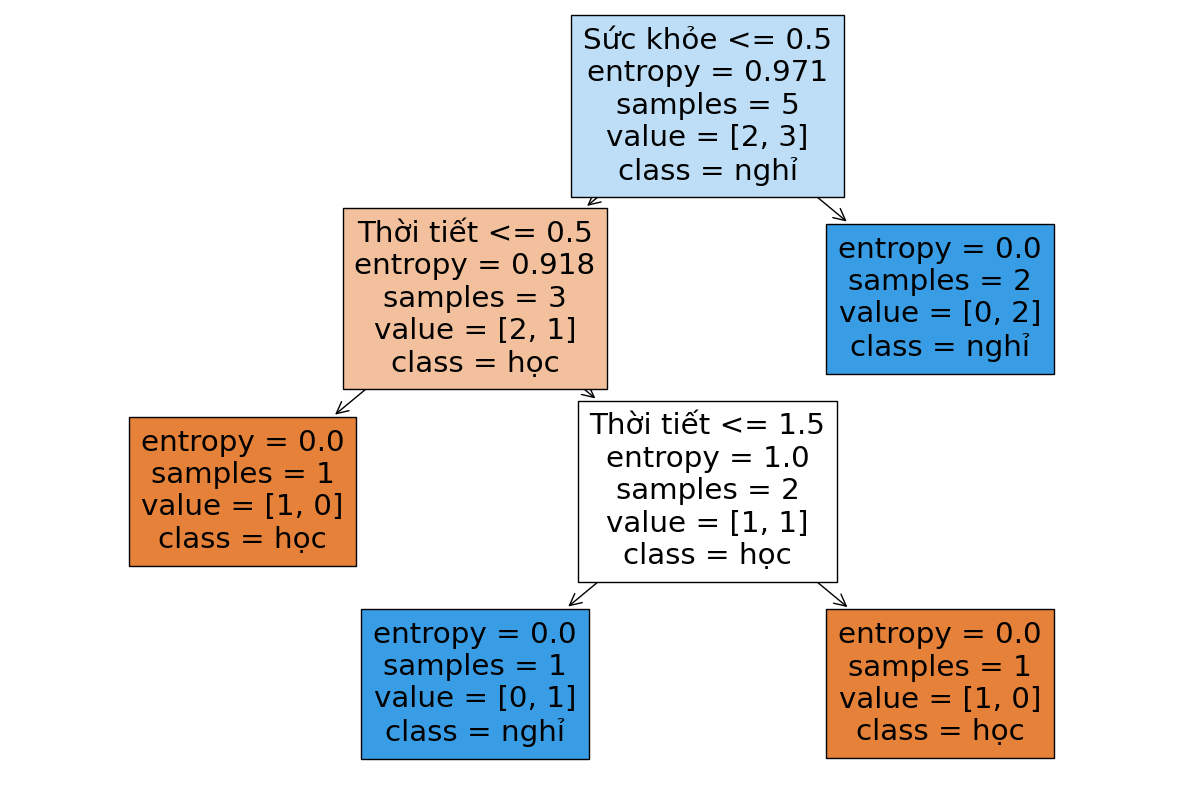

In [10]:
# Vẽ cây:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_cols = X_train.columns

plt.figure(figsize=(15,10))
plot_tree(modeIDT, feature_names= feature_cols, class_names = modeIDT.classes_, filled = True)